In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [3]:
import os
file_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(file_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


<Axes: xlabel='Age', ylabel='Count'>

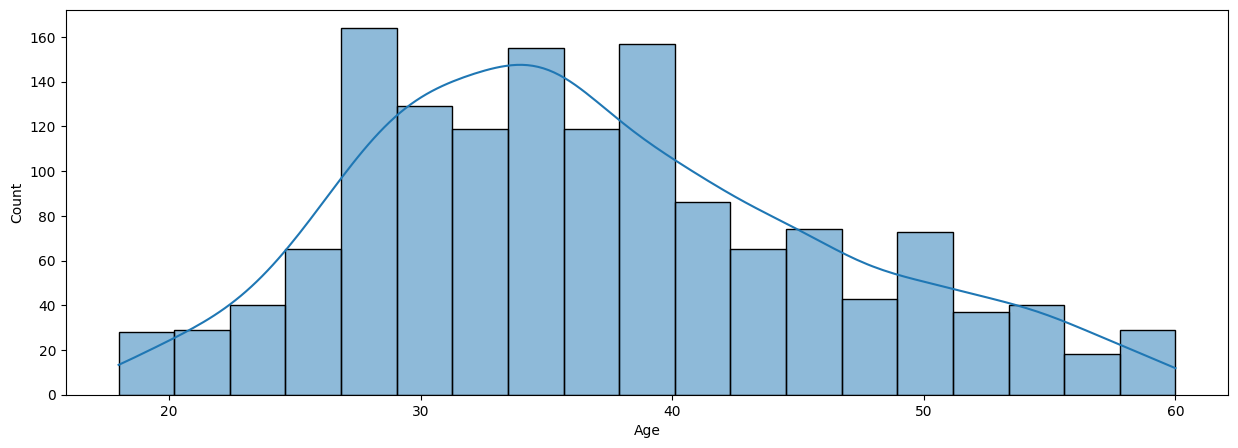

In [6]:
plt.figure(figsize=(15,5))
sns.histplot(df['Age'],kde=1)

 # Curva de densidade (kde): a linha suave sobreposta mostra a tendência da distribuição, ajudando a visualizar onde estão as maiores concentrações de valores.

curva parece ter um único pico entre 30 e 40 anos, o que sugere algo próximo de uma distribuição unimodal.



In [7]:
# skew = 0 → distribuição simétrica (normal).
# skew > 0 → cauda à direita (assimétrica positiva).
# skew < 0 → cauda à esquerda (assimétrica negativa).
# kurt = 3 → parecido com normal. Valores maiores indicam caudas mais pesadas.

print(df['Age'].skew())   # mede a assimetria
print(df['Age'].kurt())   # mede a curtose (achatamento)


0.4132863018563338
-0.4041451371872906


Skew (assimetria) = 0.41 → isso indica uma leve assimetria positiva, ou seja, a cauda da distribuição está um pouco mais alongada para a direita (idades mais altas). Não é um valor muito grande, então a distribuição ainda é relativamente próxima da simétrica.

Kurtosis (curtose) = -0.40 → isso mostra que a distribuição é um pouco mais achatada do que a normal (menos concentrada no centro e com caudas mais leves).

Em resumo:
A distribuição das idadesnão é perfeitamente normal, mas está próxima de uma curva unimodal, Ela tem uma leve tendência para valores mais altos (assimetria positiva) e é um pouco mais achatada do que a normal.

In [8]:
# teste de normalidade
# Esse teste vai te dar uma evidência estatística se os dados seguem ou não uma distribuição normal.

from scipy.stats import shapiro

stat, p = shapiro(df['Age'])
print('Estatística=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
    print("Distribuição parece normal")
else:
    print("Distribuição não é normal")


Estatística=0.977, p=0.000
Distribuição não é normal


Em resumo:

O p-valor < 0.05 indica que rejeitamos a hipótese nula de normalidade.

Ou seja, a distribuição das idades não segue uma distribuição normal.

Isso confirma o que já vimos no histograma e nas medidas de assimetria/curtose: os dados têm uma forma própria, com pico entre 30–40 anos, mas não se encaixam perfeitamente na curva normal.

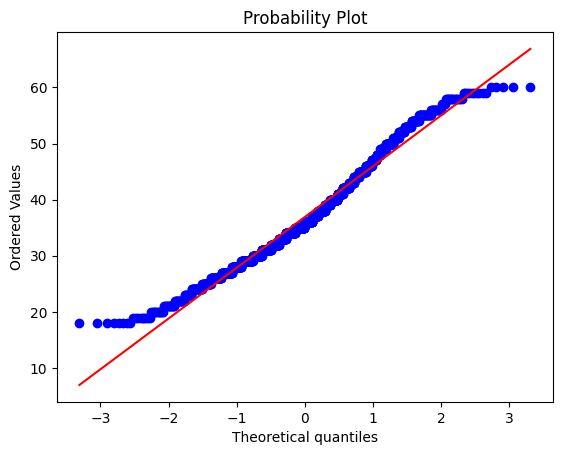

In [9]:
# Esse gráfico mostra se os pontos seguem a linha reta da normal.
# Transformações (log, Box-Cox, etc.) se você precisar aproximar a normalidade para análises estatísticas que exigem isso.
# Ou simplesmente aceitar que sua variável "Age" tem uma distribuição própria, o que é comum em dados demográficos.

import scipy.stats as stats

stats.probplot(df['Age'], dist="norm", plot=plt)
plt.show()


#Os pontos azuis representam os quantis dos seus dados de idade.
# A linha vermelha é a referência de uma distribuição normal.

O que deu para descobrir sobre a coluna Age:

O histograma mostrou que a maioria dos funcionários está na faixa dos 30–40 anos.

O teste de normalidade (Shapiro-Wilk) e o QQ-plot confirmaram que a distribuição não é normal.

# Isso é esperado em dados de RH, porque a idade dos funcionários geralmente segue padrões organizacionais (contratações, aposentadorias, etc.), e não uma curva normal perfeita.

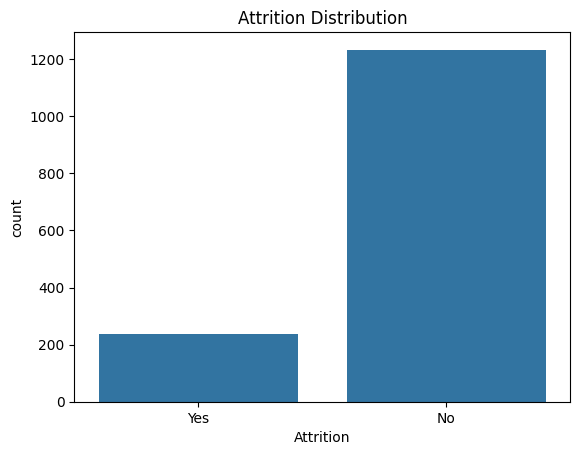

In [10]:
# total de atrtito
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

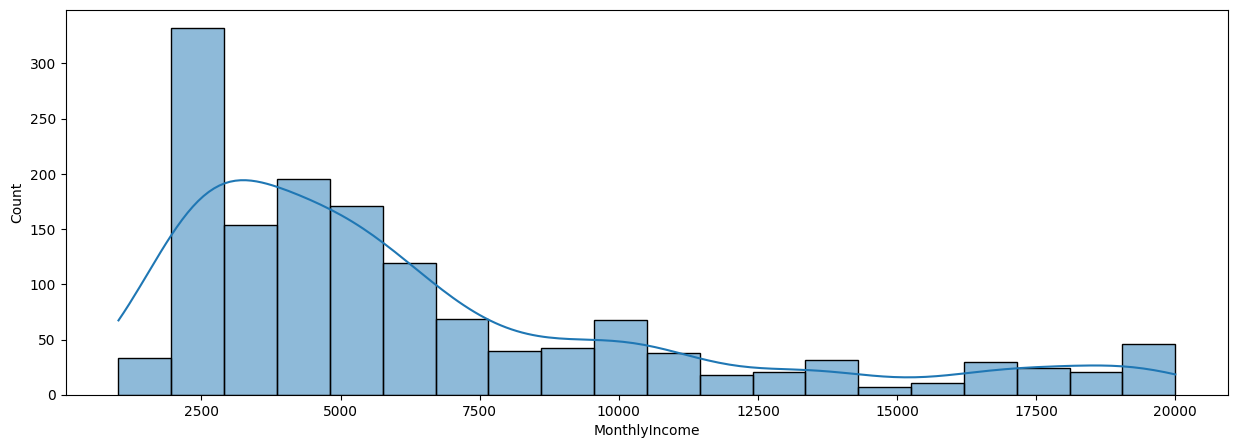

In [11]:

# MonthlyIncome
# visualização da renda mensal

plt.figure(figsize=(15, 5))

sns.histplot(df['MonthlyIncome'],kde=True)

<Axes: xlabel='Age', ylabel='Count'>

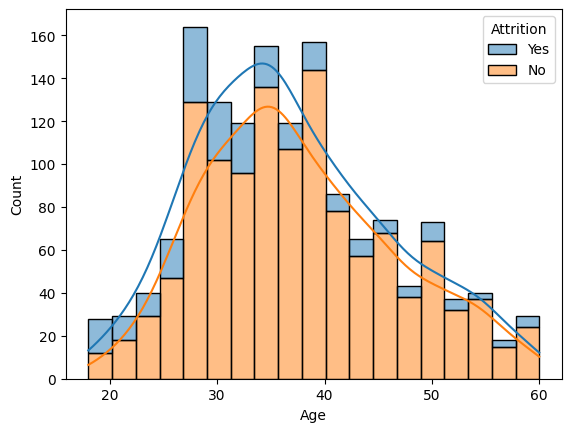

In [16]:
# Pergunta: Funcionários que saíram da empresa estão concentrados em alguma faixa etária?
# Attrition (rotatividade) vs. Age

sns.histplot(data=df, x="Age", hue="Attrition", multiple="stack", kde=True)


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Sales Executive'),
  Text(1, 0, 'Research Scientist'),
  Text(2, 0, 'Laboratory Technician'),
  Text(3, 0, 'Manufacturing Director'),
  Text(4, 0, 'Healthcare Representative'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Sales Representative'),
  Text(7, 0, 'Research Director'),
  Text(8, 0, 'Human Resources')])

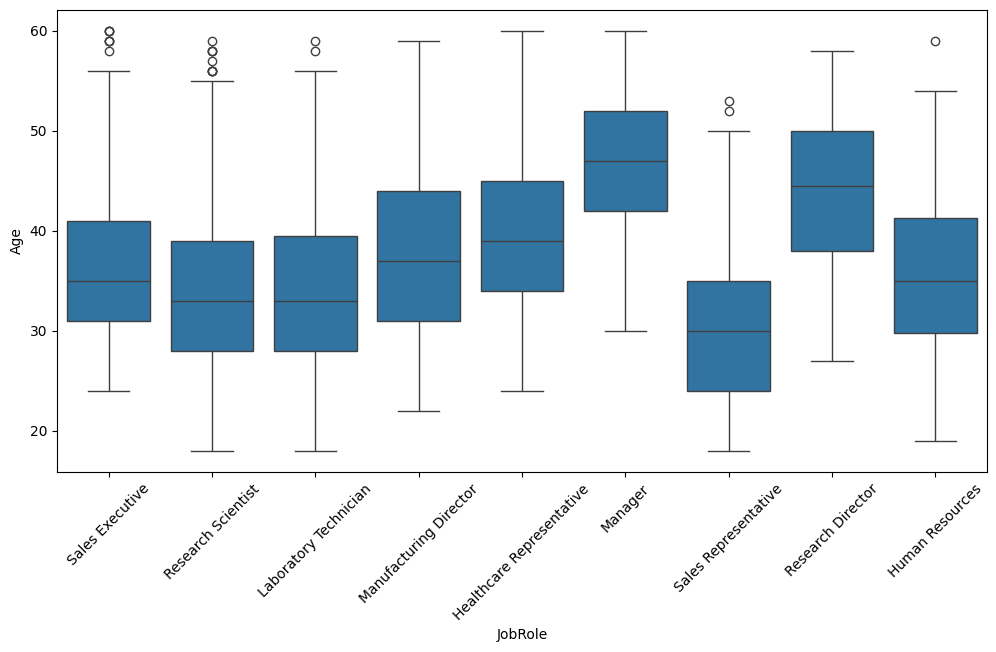

In [15]:
# Pergunta: Certos cargos ou departamentos têm perfis de idade diferentes?
# JobRole / Department vs. Age

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="JobRole", y="Age")
plt.xticks(rotation=45)


<Axes: xlabel='Age', ylabel='YearsAtCompany'>

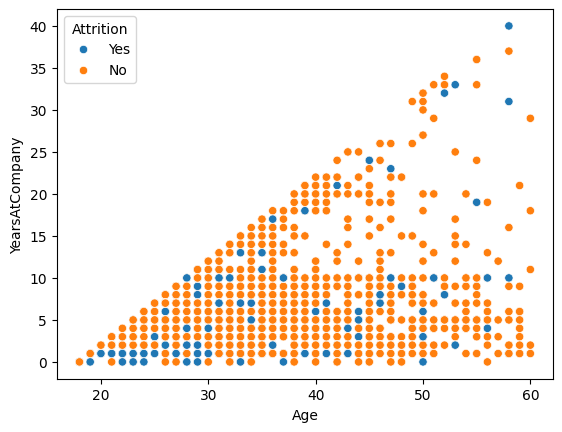

In [14]:
# Pergunta: Como idade se relaciona com tempo de empresa e experiência total?
# YearsAtCompany / TotalWorkingYears vs. Age

sns.scatterplot(data=df, x="Age", y="YearsAtCompany", hue="Attrition")


<Axes: xlabel='JobSatisfaction', ylabel='Age'>

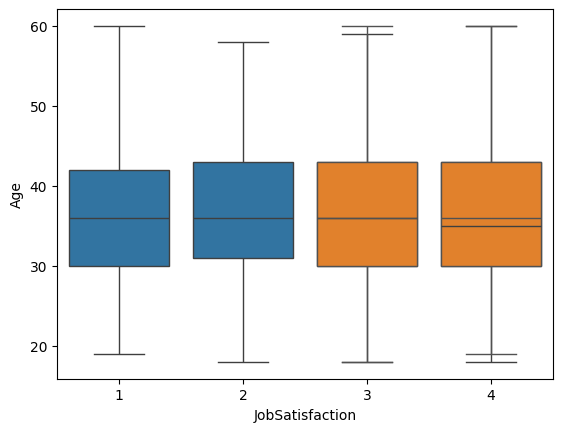

In [17]:
# Pergunta: Idade influencia satisfação ou desempenho?
# PerformanceRating / JobSatisfaction vs. Age

sns.boxplot(data=df, x="JobSatisfaction", y="Age")
sns.boxplot(data=df, x="PerformanceRating", y="Age")


###  JobSatisfaction vs. Age (boxplot)
- Funcionários com diferentes níveis de satisfação têm distribuições de idade relativamente próximas.  
- Não há uma diferença gritante, mas dá para notar que níveis mais altos de satisfação tendem a incluir funcionários um pouco mais velhos.  
- Isso sugere que a satisfação pode estar ligada à estabilidade ou maturidade na carreira.

---

###  Attrition vs. Age (scatterplot com YearsAtCompany)
- Funcionários mais jovens e com pouco tempo de empresa aparecem com maior incidência de **Attrition = Yes**.  
- Já os mais velhos, com muitos anos de casa, tendem a permanecer (Attrition = No).  
- Isso indica que a rotatividade é mais comum entre recém-contratados ou profissionais em início de carreira.

---

###  JobRole vs. Age (boxplot)
- Cargos de liderança (Manager, Director) têm medianas de idade mais altas.  
- Funções técnicas ou de entrada (Technician, Sales Representative) concentram idades mais baixas.  
- Isso reflete o ciclo natural de carreira: cargos de maior responsabilidade são ocupados por profissionais mais experientes.

---

### Attrition vs. Age (histograma com hue)
- A maior parte dos funcionários está entre 25–40 anos.  
- A rotatividade (Attrition = Yes) é mais alta entre os mais jovens, especialmente abaixo dos 30.  
- Funcionários acima dos 40 têm menor probabilidade de sair, mostrando maior retenção nessa faixa.

---

**Resumo dos achados até agora**:
- Rotatividade é maior entre jovens e iniciantes na empresa.  
- Idade média aumenta conforme o cargo é mais sênior.  
- Satisfação no trabalho parece levemente maior em faixas etárias mais altas.  
- A força de trabalho é predominantemente adulta jovem (25–40 anos).  


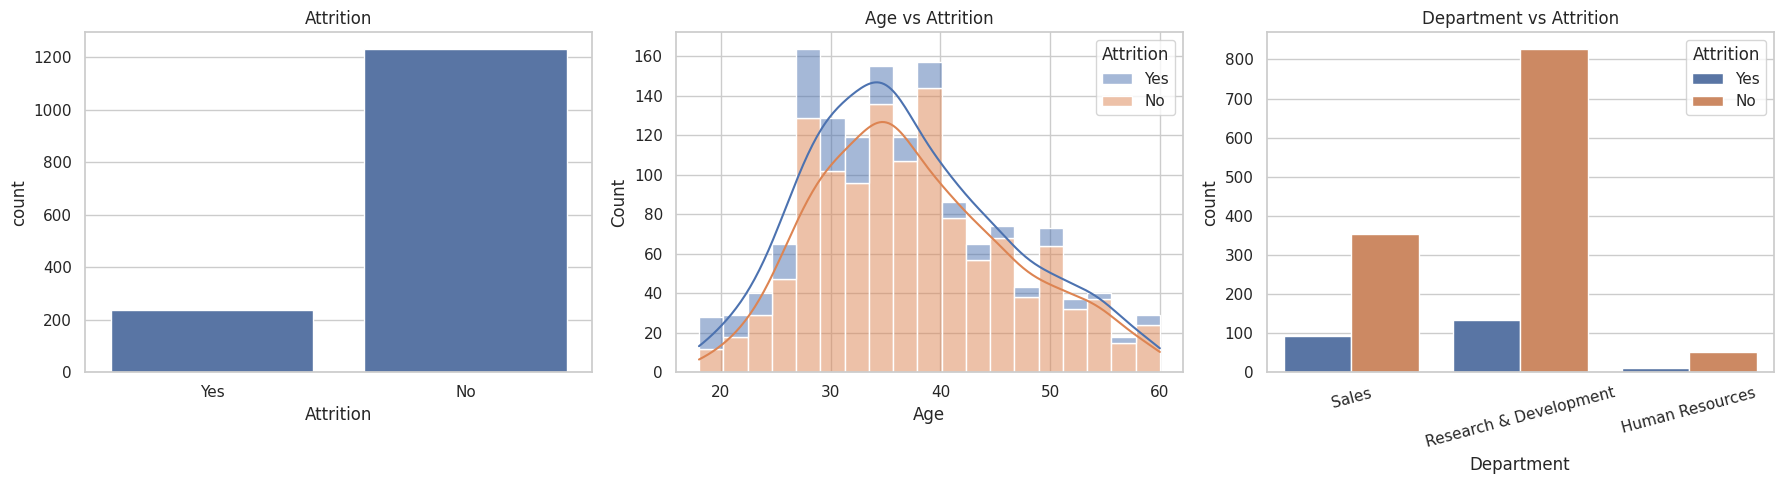

In [30]:
# Quais grupos têm maior probabilidade de sair da empresa
# Rotatividade (Attrition)

sns.set_theme(style="whitegrid")

# cria 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Attrition

sns.countplot(
    data=df,
    x="Attrition",
    ax=axes[0]
)

axes[0].set_title("Attrition")

# 2. Age

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    multiple="stack",
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Age vs Attrition")

# 3. Department

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition",
    ax=axes[2]
)

axes[2].set_title("Department vs Attrition")

# gira os nomes do eixo X
axes[2].tick_params(axis='x', rotation=15)

# ajusta espaços automaticamente
plt.tight_layout()

plt.show()

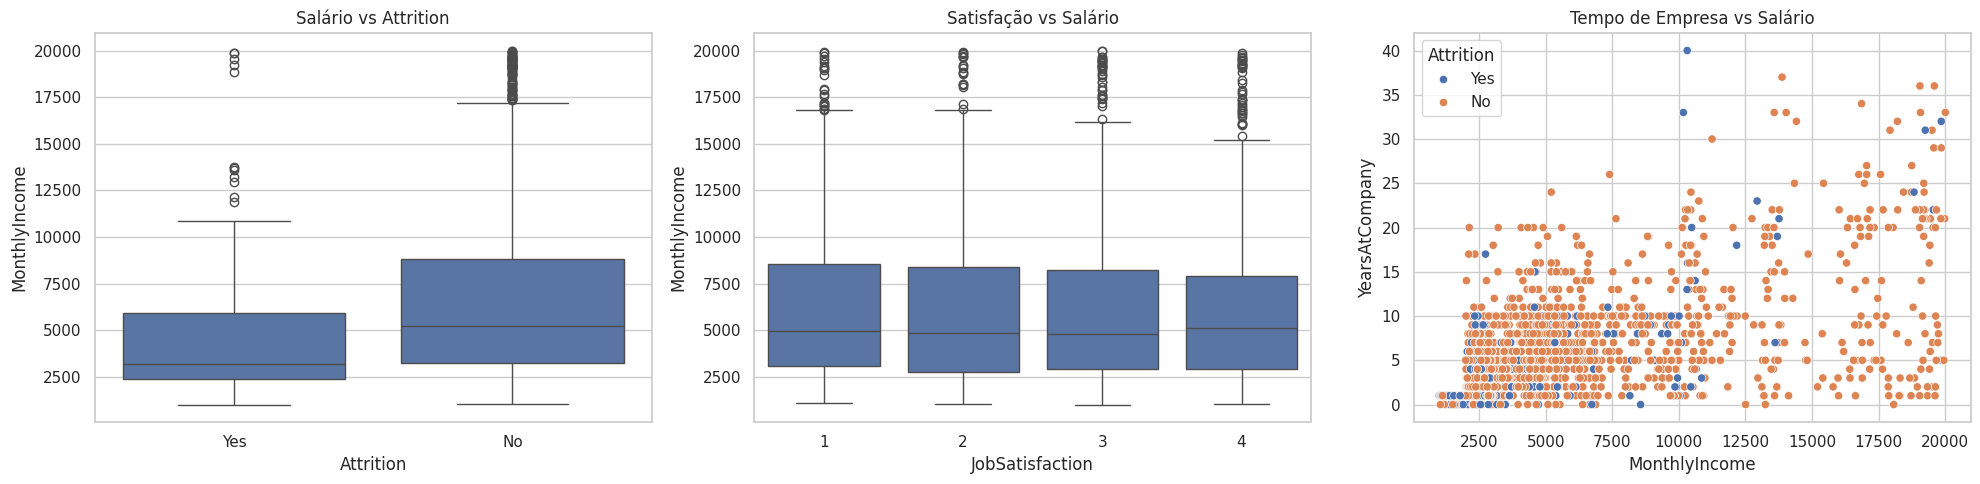

In [33]:
# Salário e benefícios
# Pergunta:Renda influencia satisfação ou saída?

sns.set_theme(style="whitegrid")

# cria a figura
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Attrition vs MonthlyIncome

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    ax=axes[0]
)

axes[0].set_title("Salário vs Attrition")

# 2. JobSatisfaction vs MonthlyIncome

sns.boxplot(
    data=df,
    x="JobSatisfaction",
    y="MonthlyIncome",
    ax=axes[1]
)

axes[1].set_title("Satisfação vs Salário")

# 3. Income vs YearsAtCompany

sns.scatterplot(
    data=df,
    x="MonthlyIncome",
    y="YearsAtCompany",
    hue="Attrition",
    ax=axes[2]
)

axes[2].set_title("Tempo de Empresa vs Salário")

# ajusta espaços
plt.tight_layout()

plt.show()

/tmp/ipykernel_6471/3201194872.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6471/3201194872.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


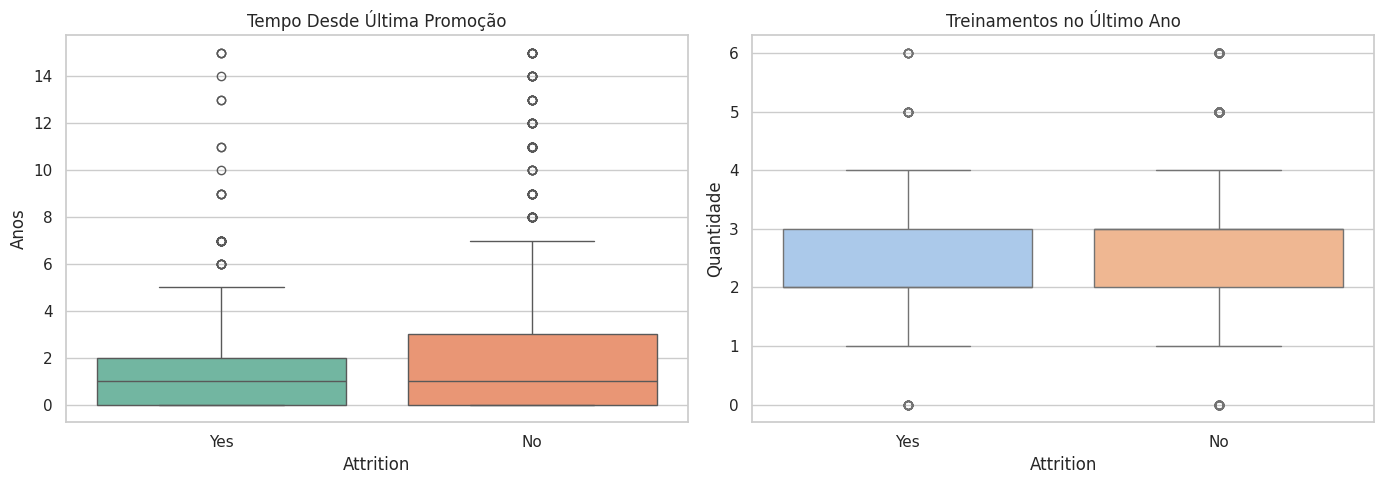

In [36]:
# Treinamento e desenvolvimento
# Analisar se promoções e treinamentos impactam retenção

sns.set_theme(style="whitegrid")

# cria os gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Promoção vs Attrition

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsSinceLastPromotion",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Tempo Desde Última Promoção")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Anos")

# 2. Treinamentos vs Attrition

sns.boxplot(
    data=df,
    x="Attrition",
    y="TrainingTimesLastYear",
    palette="pastel",
    ax=axes[1]
)

axes[1].set_title("Treinamentos no Último Ano")
axes[1].set_xlabel("Attrition")
axes[1].set_ylabel("Quantidade")

# ajusta espaçamento
plt.tight_layout()

plt.show()


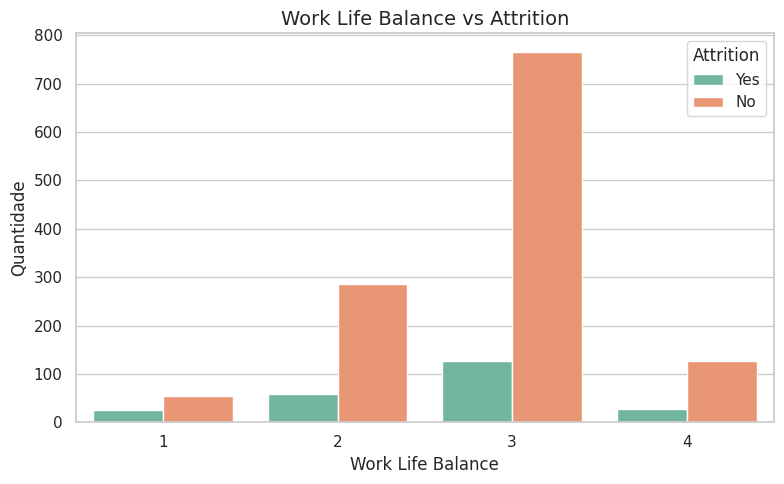

In [38]:
# Work-Life Balance
# Verificar se equilíbrio vida-trabalho influencia rotatividade.

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition",
    palette="Set2"
)

plt.title("Work Life Balance vs Attrition", fontsize=14)
plt.xlabel("Work Life Balance")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.show()


/tmp/ipykernel_6471/3837314425.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6471/3837314425.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6471/3837314425.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


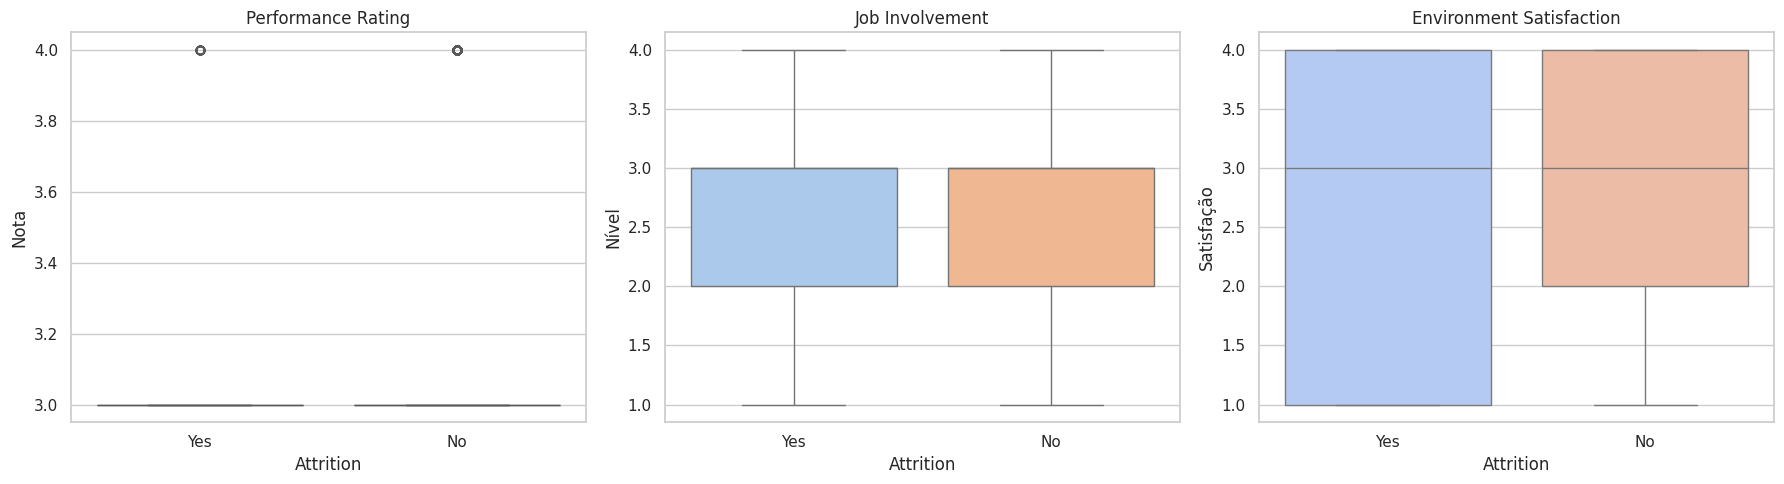

In [39]:
# Performance e envolvimento
# Entender se desempenho e envolvimento afetam retenção.

sns.set_theme(style="whitegrid")

# cria os 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PerformanceRating

sns.boxplot(
    data=df,
    x="Attrition",
    y="PerformanceRating",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Performance Rating")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Nota")

# 2. JobInvolvement

sns.boxplot(
    data=df,
    x="Attrition",
    y="JobInvolvement",
    palette="pastel",
    ax=axes[1]
)

axes[1].set_title("Job Involvement")
axes[1].set_xlabel("Attrition")
axes[1].set_ylabel("Nível")

# 3. EnvironmentSatisfaction

sns.boxplot(
    data=df,
    x="Attrition",
    y="EnvironmentSatisfaction",
    palette="coolwarm",
    ax=axes[2]
)

axes[2].set_title("Environment Satisfaction")
axes[2].set_xlabel("Attrition")
axes[2].set_ylabel("Satisfação")

# ajusta espaçamento
plt.tight_layout()

plt.show()

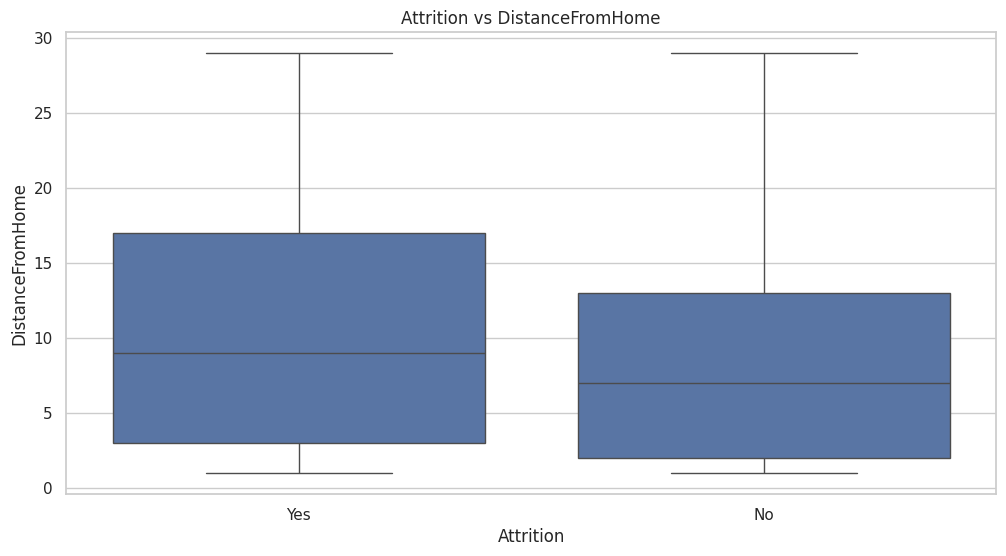

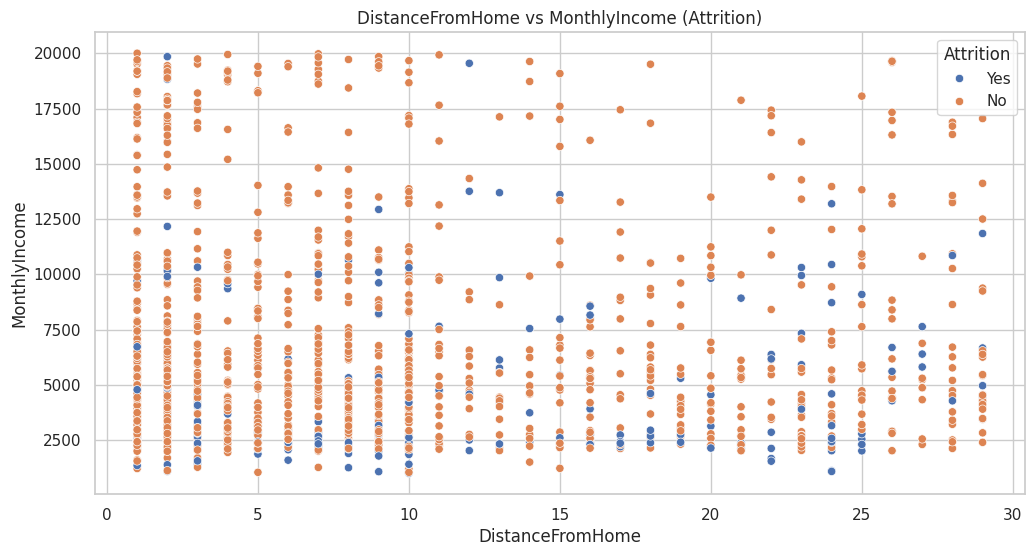

In [41]:
# Boxplot – Attrition vs DistanceFromHome
# Eixo X (Attrition): separa quem saiu da empresa (Yes) e quem ficou (No).
# Eixo Y (DistanceFromHome): mostra a distância da casa até o trabalho.

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
plt.title("Attrition vs DistanceFromHome")
plt.show()

# Scatterplot – DistanceFromHome vs MonthlyIncome (Attrition)
# Eixo X (DistanceFromHome): distância da casa até o trabalho.
# Eixo Y (MonthlyIncome): salário mensal.

plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x="DistanceFromHome", y="MonthlyIncome", hue="Attrition")
plt.title("DistanceFromHome vs MonthlyIncome (Attrition)")
plt.show()


### 1. **Attrition (Rotatividade)**
- A maioria dos funcionários permanece, mas há cerca de 200 casos de saída.  
- A saída é mais comum entre **funcionários jovens (30–35 anos)** e em alguns departamentos específicos, como **Sales**.  
- Rotatividade concentrada em início de carreira e áreas comerciais.

---

### 2. **Salário e benefícios**
- Funcionários que ficaram (`No`) têm **salários medianos mais altos** e maior variação de renda.  
- A satisfação no trabalho não varia muito com salário, mas quem ganha mais tende a permanecer.  
- Funcionários com **longa permanência e salários altos** quase não apresentam rotatividade.  
- Salário e tempo de empresa são fatores de retenção.

---

### 3. **Treinamento e desenvolvimento**
- Tempo desde a última promoção: quem saiu (`Yes`) tem mediana menor (cerca de 1 ano), enquanto quem ficou tem mediana maior (~2 anos).  
- Treinamentos no último ano: distribuição semelhante entre os grupos, sem grande impacto direto.  
- Promoções parecem ter mais influência na retenção do que treinamentos.

---

### 4. **Work-Life Balance**
- Funcionários com equilíbrio **nível 3** são maioria e têm menor rotatividade.  
- Níveis mais baixos (1 e 2) apresentam proporção maior de saída.  
- Equilíbrio vida-trabalho é um fator importante para retenção.

---

### 5. **Performance e envolvimento**
- Performance Rating não mostra diferença significativa entre quem saiu e quem ficou.  
- Job Involvement e Environment Satisfaction também têm distribuições semelhantes, mas níveis mais baixos aparecem com maior proporção de saída.  
- Desempenho não explica a saída, mas envolvimento e satisfação ambiental podem contribuir.

---

### 6. **Perfil demográfico**
- Funcionários que moram mais longe têm maior rotatividade (boxplot de DistanceFromHome).  
- Estado civil e gênero podem ser explorados, mas geralmente não são os principais fatores.  
- Distância da casa até o trabalho é um fator relevante para explicar saída.

---

 **Resumo geral da análise exploratória (EDA):**
- **Rotatividade maior entre jovens, cargos de entrada e áreas comerciais.**  
- **Salário e tempo de empresa são fortes fatores de retenção.**  
- **Promoções e equilíbrio vida-trabalho influenciam saída.**  
- **Distância da casa até o trabalho aumenta probabilidade de rotatividade.**  
- **Desempenho não é determinante, mas satisfação e envolvimento ajudam.**



Let's identify columns that can be eliminated due to having constant values or being unique identifiers.

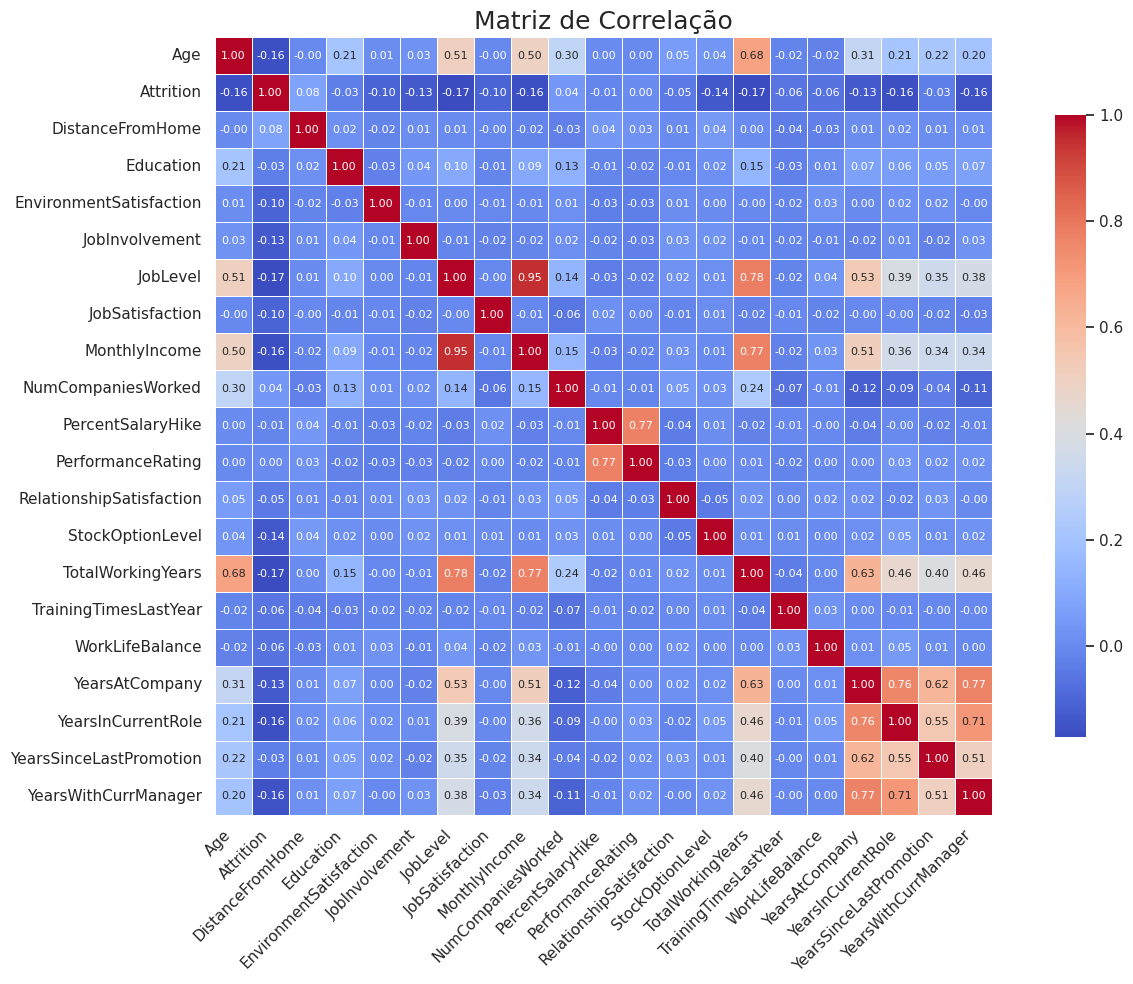

In [62]:
# estilo visual
sns.set_theme(style="white")

# figura maior
plt.figure(figsize=(14, 10))

# copia do dataframe
df_temp = df.copy()

# remove colunas irrelevantes ou constantes
df_temp = df_temp.drop(columns=[
    "EmployeeCount", "StandardHours", "EmployeeNumber", "Over18",
    "DailyRate", "HourlyRate", "MonthlyRate"  # redundantes de MonthlyIncome
])

# transforma Attrition em numérico
df_temp["Attrition"] = df_temp["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# matriz de correlação
corr = df_temp.corr(numeric_only=True)

# heatmap melhorado
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

# título
plt.title("Matriz de Correlação", fontsize=18)

# melhora labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# ajusta layout
plt.tight_layout()

plt.show()

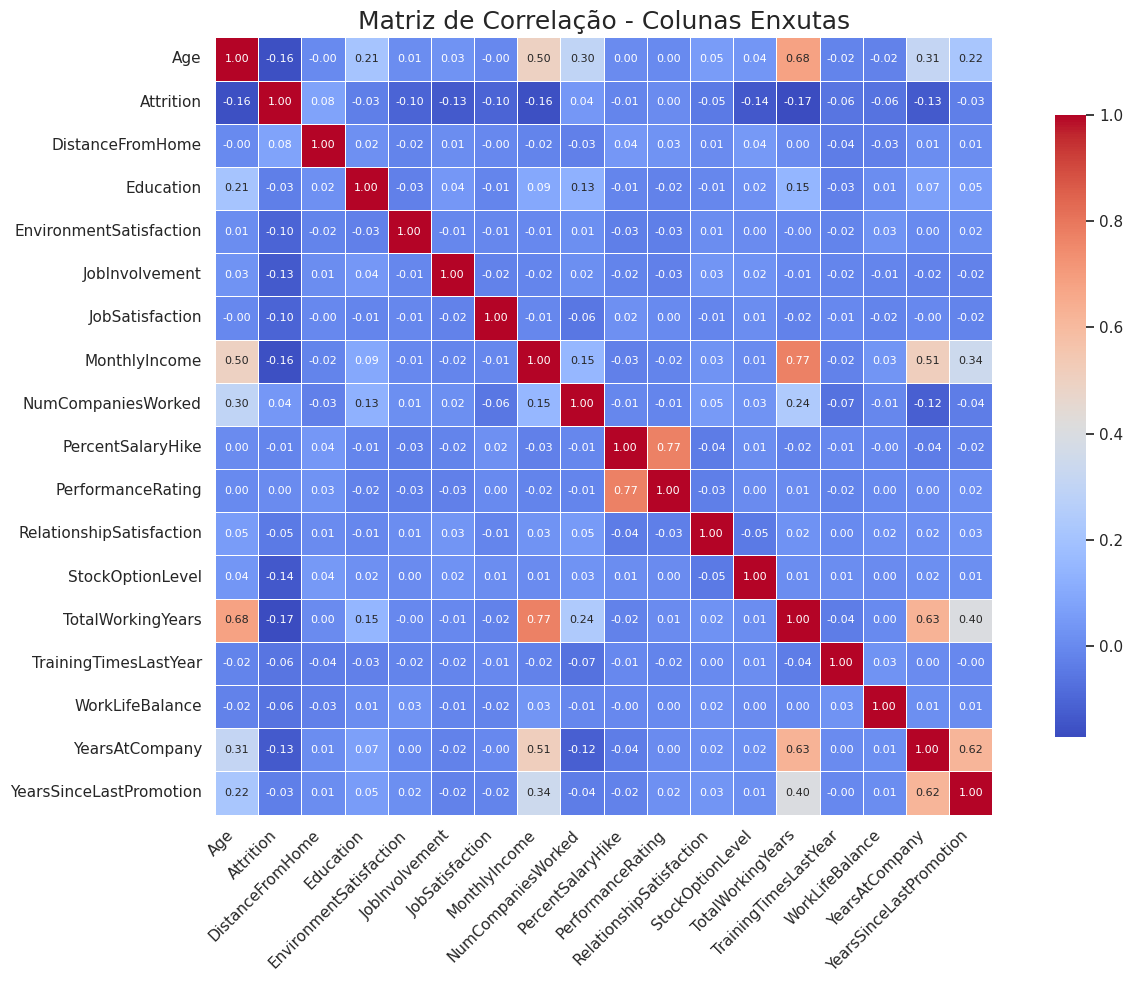

In [64]:
# copia do dataframe
df_temp = df.copy()

# remove colunas irrelevantes ou constantes
df_temp = df_temp.drop(columns=[
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber",
    "Over18",
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "JobLevel"
])

# transforma Attrition em numérico
df_temp["Attrition"] = df_temp["Attrition"].map({"Yes": 1, "No": 0})

# matriz de correlação
corr = df_temp.corr(numeric_only=True)

# estilo visual
sns.set_theme(style="white")

# figura maior
plt.figure(figsize=(14, 10))

# heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

# título
plt.title("Matriz de Correlação - Colunas Enxutas", fontsize=18)

# labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# layout
plt.tight_layout()
plt.show()


In [65]:

# Cópia do dataset

df_model = df.copy()

# Removendo colunas desnecessárias

df_model = df_model.drop(columns=[
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber",
    "Over18",
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "JobLevel"
])

# Target (Attrition)

df_model["Attrition"] = df_model["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Encoding das variáveis categóricas

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

# Verificando dataset final

print(df_model.shape)

display(df_model.head())

(1470, 39)


,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1,2,2,3,4,5993,8,11,...,False,False,False,False,False,True,False,False,True,True
1,49,0,8,1,3,2,2,5130,1,23,...,False,False,False,False,True,False,False,True,False,False
2,37,1,2,2,4,2,3,2090,6,15,...,True,False,False,False,False,False,False,False,True,True
3,33,0,3,4,4,3,3,2909,1,11,...,False,False,False,False,True,False,False,True,False,True
4,27,0,2,1,1,3,2,3468,9,12,...,True,False,False,False,False,False,False,True,False,False


In [66]:
# salva dataset pronto para modelagem

df_model.to_csv(
    "hr_attrition_processed.csv",
    index=False
)

print("Dataset salvo com sucesso.")

Dataset salvo com sucesso.


In [67]:
df_model.to_csv("hr_attrition_processed.csv", index=False)